# Experiment Tracking
Experimenting of diff models and investigate which works the best. when we try many models, how to track them?
> There are diff ways to track experiments like:
* Tensorboard
* Weights&biases
* ML flow
* Python dictionaries

https://towardsdatascience.com/a-comprehensive-comparison-of-ml-experiment-tracking-tools-9f0192543feb/

In [1]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.6.0+cu124
0.21.0+cu124


In [2]:
def set_seed(seed: int = 42):
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)

In [3]:
set_seed()

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
# Import torchinfo & going_modular

try:
  from torchinfo import summary
except:
  !pip install -q torchinfo
  from torchinfo import summary

try:
  from going_modular import data_setup, engine
except:
  !git clone -q https://github.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice
  !mv pytorch-zero-to-mastery-MyPractice/going_modular .
  !rm -rf pytorch-zero-to-mastery-MyPractice
  from going_modular import data_setup, engine

## 1. Get Data

### 1.1 Method 1: get data by cloning GitHub repository

In [6]:
import zipfile
from pathlib import Path

# Set paths
data_dir = Path("data/")
extract_path = data_dir / "pizza_steak_sushi"
zip_path = data_dir / "pizza_steak_sushi.zip"

if extract_path.is_dir():
    print("[INFO] Data already exists, skipping downloading...")

else:
    # Get the data from github
    !git clone -q https://github.com/mrdbourke/pytorch-deep-learning/
    !mv pytorch-deep-learning/data .
    !rm -rf pytorch-deep-learning

    # Unzip the file
    with zipfile.ZipFile(zip_path, "r") as zip_file:
        print(f"[info] Unzipping the data to {extract_path}...")
        zip_file.extractall(extract_path)

    # 2. Delete all files in data/ except the extracted folder
    for item in data_dir.iterdir():
        if item.is_file(): # to remove any other files like "png", "zip",..etc
            item.unlink()
        elif item.is_dir() and item.name != "pizza_steak_sushi": # To remove any other dir exist in "data/" dir
            import shutil
            shutil.rmtree(item)

    print("[info] Done: zip file removed and only extracted folder remains.")


[info] Unzipping the data to data/pizza_steak_sushi...
[info] Done: zip file removed and only extracted folder remains.


### 1.2 Method 2: Get data by downloading using `requests.get(url)`

In [7]:
import requests
from pathlib import Path

import os
import zipfile

def download_data(source: str ,
                  destination: str,
                  remove_source: bool = True) -> Path:
    """ Download dataset as zipped file from source and extract zipped file to destination.
    """

    # Setup path to data folder
    path_dir = Path("data/")
    extract_path = path_dir / destination

    # If image folder doesn't exist, create it
    if extract_path.is_dir():
      print(f"[INFO] {extract_path} directory already exists, skipping download.")
    else:
      print(f"[INFO] did not find {extract_path}, directory, creating one.")
      extract_path.mkdir(parents=True, exist_ok=True)

      # Download the target data
      target_file = Path(source).name # How to get the name of the dataset

      with open(path_dir / target_file, "wb") as f:
        request = requests.get(source)
        print(f"[INFO] Downloading the dataset from {source}.")
        f.write(request.content)

      with zipfile.ZipFile(path_dir / target_file, "r") as zip_ref:
        print(f"[INFO] Unzipping the dataset to {extract_path}.")
        zip_ref.extractall(extract_path)

      # Remove .zip file if needed
      if remove_source:
        #!rm -rf target_file
        os.remove(path_dir / target_file)
        print(f"[INFO] Removing {target_file} file.")

    return extract_path

In [8]:
extract_path = download_data(source= "https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip",
                            destination= "pizza_steak_sushi")
print(f"[INFO] Dataset is located in {extract_path}")

[INFO] data/pizza_steak_sushi directory already exists, skipping download.
[INFO] Dataset is located in data/pizza_steak_sushi


## 2. Transforming the data into Datasets & Dataloaders

### 2.1 Create DataLoaders with manual transforms

In [9]:
from torchvision import transforms

from going_modular import data_setup

# Setup the train and test directories
train_dir = extract_path / "train"
test_dir = extract_path / "test"

# Create transforms manually
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]) # We get this info from the FM documentation, not needed if auto created

manual_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])
print(f"Manually created transforms: {manual_transform}")

# Create dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=manual_transform,
                                                                               batch_size=32)

train_dataloader, test_dataloader, class_names

Manually created transforms: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


(<torch.utils.data.dataloader.DataLoader at 0x7d5ec4c05290>,
 ['pizza', 'steak', 'sushi'])

### 2.2 Create dataloaders using automatically created transforms using `torchvision.models`

In [10]:
from going_modular import data_setup
import torchvision

# Setup the train and test directories
train_dir = extract_path / "train"
test_dir = extract_path / "test"

# automatically Create transforms

# Setup pretrained weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

# Get transforms which used to train the weights
auto_transform = weights.transforms()
print(f"Auto created transforms: {auto_transform}")


# Create dataloaders
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transform,
                                                                               batch_size=32)

train_dataloader, test_dataloader, class_names

Auto created transforms: ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


(<torch.utils.data.dataloader.DataLoader at 0x7d5ec4c0ea90>,
 ['pizza', 'steak', 'sushi'])

## 3. Get a pre-trained mode, freeze the hidden layers
https://docs.pytorch.org/vision/master/models/generated/torchvision.models.efficientnet_b0.html#torchvision.models.EfficientNet_B0_Weights

In [11]:
# Import the weights and model
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

summary(model,
        input_size=(1,3,224,224),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings= ["var_names"])

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 92.3MB/s]


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

In [12]:
import torch
from torch import nn

# Freeze training
for param in model.features.parameters():
  param.requires_grad= False

# Fit the classifier to our problem
model.classifier = nn.Sequential(
                                nn.Dropout(p=0.2, inplace=True),
                                nn.Linear(in_features=1280,
                                          out_features=len(class_names))
).to(device)

summary(model,
        input_size=(1,3,224,224),
        verbose=0,
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

## 4. Train a single model and track results
`torch.utils.tensorboard` https://docs.pytorch.org/docs/stable//tensorboard.html

In [13]:
# Define loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),
                             lr=0.001)

In [14]:
# Setup a summarywriter
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()
writer

In [15]:
from going_modular.engine import train_step, test_step
from tqdm.auto import tqdm
from typing import Dict, Tuple, List

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device) -> Dict[str, List[float]]:
    """Runs training and testing for a number of epochs and tracks metrics.

    Args:
        model: A PyTorch model to be tested.
        train_dataloader: A train dataloader instance for the train dataset.
        test_dataloader: A test dataloader instance for the test dataset.
        loss_fn: A PyTorch loss function to minimiz.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        epochs: An integer indicating the number of epochs to be trained for.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A Dictionary of training and testing loss as well as training and testing accuracy metrics,
        each metric has values in the form of list, in the form:
            {
              "train_loss": [...],
              "train_acc": [...],
              "test_loss": [...],
              "test_acc": [...]
            }

        Example, if number of epochs is 3:
            {
              "train_loss": [0.4352, 0.3456, 0.2357],
              "train_acc": [0.8765, 0.8854, 0.8976],
              "test_loss": [0.7658, 0.6789, 0.5498],
              "test_acc": [0.7895, 0.7890, 0.7998]
            }


    Example usage:
        Results = train(
            model=model,
            train_dataloader= path/to/train/DataLoader,
            test_dataloader= path/to/test/DataLoader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            epochs= 5,
            device=device
        )
    """

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        ### Experiment tracking ###
        writer.add_scalars(main_tag="Loss",
                           tag_scalar_dict={"train_loss": train_loss,
                                            "test_loss": test_loss},
                           global_step=epoch)

        writer.add_scalars(main_tag="Accuracy",
                           tag_scalar_dict={"train_acc": train_acc,
                                            "test_acc": test_acc},
                           global_step=epoch)

        writer.add_graph(model=model,
                         input_to_model=torch.randn(32,3,224,224).to(device))

        writer.close()

    return results

In [16]:
# Train model
set_seed()
results = train(model=model,
          train_dataloader=train_dataloader,
          test_dataloader=test_dataloader,
          loss_fn=loss_fn,
          optimizer=optimizer,
          epochs=5,
          device=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0855 | train_acc: 0.4180 | test_loss: 0.9122 | test_acc: 0.6506
Epoch: 2 | train_loss: 0.8571 | train_acc: 0.8008 | test_loss: 0.8404 | test_acc: 0.6619
Epoch: 3 | train_loss: 0.8089 | train_acc: 0.6953 | test_loss: 0.7064 | test_acc: 0.7528
Epoch: 4 | train_loss: 0.6980 | train_acc: 0.7891 | test_loss: 0.6586 | test_acc: 0.7926
Epoch: 5 | train_loss: 0.5723 | train_acc: 0.9062 | test_loss: 0.5874 | test_acc: 0.8447


## 5. view our model's results with tensorboard
https://docs.pytorch.org/docs/stable//tensorboard.html

In [17]:
#!kill 2032
%load_ext tensorboard
%tensorboard --logdir runs

<IPython.core.display.Javascript object>

## 6. Create a function to prepare `summarywriter()` instance
the `summarywriter()` class saves to `log_dir` folder by defualt.
to save diff expreiments to diff folders, where:
one experiment --> one folder.

Things to track in experiments:
* Experiment data/timestamp.
* Experiment name.
* Model name.
* Anything extra to be tracked.

For this purpose, we create a function that create `summarywriter()` instance to take all these things into account, and track each experiment to a directory, like:
`runs/YYYY-MM-DD/experiment_name/model_name/extra`

In [18]:
from torch.utils.tensorboard import SummaryWriter

def create_writer(experiment_name: str,
                  model_name: str,
                  extra: str = None):
    """ Create a torch.utils.tensorboard.SummaryWriter() to track a particular experiment.
    """
    from datetime import datetime
    import os

    # Get timestamp of current date in reverse order
    timestamp = datetime.now().strftime("%y-%m-%d")

    if extra:
      # Create log directory path
      log_dir = os.path.join("runs", timestamp, experiment_name, model_name, extra)
    else:
      log_dir = os.path.join("runs", timestamp, experiment_name, model_name)

    print(f"[INFO] Created SummaryWriter() saving to{log_dir}")
    return SummaryWriter(log_dir=log_dir)

In [19]:
example_writer = create_writer(experiment_name= "data_10_percent",
                               model_name= "effnetb0",
                               extra="5_epochs")

example_writer

[INFO] Created SummaryWriter() saving toruns/25-06-28/data_10_percent/effnetb0/5_epochs


### 6.1 Update the `train()` function to include `writer()` parameter

In [20]:
# Update train() to use creaate_writer()
from going_modular.engine import train_step, test_step
from tqdm.auto import tqdm
from typing import Dict, Tuple, List

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          loss_fn: torch.nn.Module,
          optimizer: torch.optim.Optimizer,
          epochs: int,
          device: torch.device,
          writer: torch.utils.tensorboard.writer.SummaryWriter) -> Dict[str, List[float]]:
    """Runs training and testing for a number of epochs and tracks metrics.

    Args:
        model: A PyTorch model to be tested.
        train_dataloader: A train dataloader instance for the train dataset.
        test_dataloader: A test dataloader instance for the test dataset.
        loss_fn: A PyTorch loss function to minimiz.
        optimizer: A PyTorch optimizer to help minimize the loss function.
        epochs: An integer indicating the number of epochs to be trained for.
        device: A target device to compute on (e.g. "cuda" or "cpu").

    Returns:
        A Dictionary of training and testing loss as well as training and testing accuracy metrics,
        each metric has values in the form of list, in the form:
            {
              "train_loss": [...],
              "train_acc": [...],
              "test_loss": [...],
              "test_acc": [...]
            }

        Example, if number of epochs is 3:
            {
              "train_loss": [0.4352, 0.3456, 0.2357],
              "train_acc": [0.8765, 0.8854, 0.8976],
              "test_loss": [0.7658, 0.6789, 0.5498],
              "test_acc": [0.7895, 0.7890, 0.7998]
            }


    Example usage:
        Results = train(
            model=model,
            train_dataloader= path/to/train/DataLoader,
            test_dataloader= path/to/test/DataLoader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            epochs= 5,
            device=device
        )
    """

    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            device=device
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            device=device
        )

        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        ### Experiment tracking ###
        if writer:
            writer.add_scalars(main_tag="Loss",
                              tag_scalar_dict={"train_loss": train_loss,
                                                "test_loss": test_loss},
                              global_step=epoch)

            writer.add_scalars(main_tag="Accuracy",
                              tag_scalar_dict={"train_acc": train_acc,
                                                "test_acc": test_acc},
                              global_step=epoch)

            writer.add_graph(model=model,
                            input_to_model=torch.randn(32,3,224,224).to(device))

            writer.close()
        else:
            pass
        ### END NOW ###

    return results

## 7. Setting up a series of modelling experiments
* setting up two experiments of effnetb0, one for 5 epochs and one for 10 epochs.


### 7.1 what kind of experiments should we run?

The number of machine learning experiments to run like number of model we can build is limitless.

But we cannot test everything for ever, so we can test:
* Change number of epochs.
* Change the number of hidden units/layers.
* Change the amount of data (in Foodmini vision we use only 10% of the Food101 dataset.).
* Change the learning rate.
* Try different data augmentation.
* Change the model architecture.

### 7.2 What experiments are we going to run?

1. Model size: EffnetB0 vs EffnetB2.
2. Dataset size: 10% vs 20%. (more data->better results.)
3. Training time: 5 epochs vs 10 epochs.(longer training->better results up to convergence.)

To start, we keep things relatively small that experiments run quickly. we start with least epochs and training data size and smallest model. increase it gradually. test data are the same to keep evaluation consistent.

|ex number | training data | model architecture | epochs |
|----------|---------------|--------------------|--------|
|1         | 10/20%           |effnetb0/b2            |5/10       |

>Goal: a model that is well performing but still small enough to run on a mobile device or web browser, so it can come to life.

>if you have infinte compute and time, always choose the biggest model and dataset you can.
https://www.cs.utexas.edu/~eunsol/courses/data/bitter_lesson.pdf

### 7.3 Download different datasets

1. 10% pizza_steak_sushi
2. 20% pizza_steak_sushi

In [21]:
!rm -rf data/

In [22]:
# Download 10 percent and 20 percent datasets
data_10_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip",
                                     destination="pizza_steak_sushi")
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

[INFO] did not find data/pizza_steak_sushi, directory, creating one.
[INFO] Downloading the dataset from https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip.
[INFO] Unzipping the dataset to data/pizza_steak_sushi.
[INFO] Removing pizza_steak_sushi.zip file.
[INFO] did not find data/pizza_steak_sushi_20_percent, directory, creating one.
[INFO] Downloading the dataset from https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi_20_percent.zip.
[INFO] Unzipping the dataset to data/pizza_steak_sushi_20_percent.
[INFO] Removing pizza_steak_sushi_20_percent.zip file.


### 7.4 Transform datasets and create dataloaders
1. Resize to (224,224).
2. Image tensor valuse are between [0, 1]
3. Normalize the images so they have same data distribution as imageNet.

In [23]:
# Setup training dir paths
train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"

# Setup the test dir, it will be the same for both
test_dir = data_10_percent_path / "test"

train_dir_10_percent, train_dir_20_percent

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/train'))

In [24]:
from torchvision import transforms

# Create transforms manually
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]) # We get this info from the FM documentation, not needed if auto created

# Compose transforms into a pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

In [25]:
BATCH_SIZE = 32

train_dataloader_10_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_10_percent,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transform,
                                                                               batch_size=BATCH_SIZE)

train_dataloader_20_percent, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transform,
                                                                               batch_size=BATCH_SIZE)

print(f"Number of batches of size {BATCH_SIZE} is 10% train data: {len(train_dataloader_10_percent)}")
print(f"Number of batches of size {BATCH_SIZE} is 20% train data: {len(train_dataloader_20_percent)}")
print(f"Number of batches of size {BATCH_SIZE} is 10% test data: {len(test_dataloader)}")
print(f"Class names: {class_names}")

Number of batches of size 32 is 10% train data: 8
Number of batches of size 32 is 20% train data: 15
Number of batches of size 32 is 10% test data: 3
Class names: ['pizza', 'steak', 'sushi']


### 7.5 Create feature extractor models

we want two functions:
1. `torchvision.models.efficientnet_b0()`
2. `torchvision.models.efficientnet_b2()`

> both with frozen base and custom classifier.


In [26]:
import torchvision
from torch import nn

effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT # DEFAULT = best available model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)

summary(model=effnetb2,
        input_size=(1,3,224,224),
        verbose=0, # how many details printed, 0 for minimal
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth
100%|██████████| 35.2M/35.2M [00:00<00:00, 154MB/s]


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

In [27]:
for param in effnetb2.features.parameters():
  param.requires_grad=False

effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True),
    nn.Linear(in_features=1408, out_features=len(class_names))
)

summary(model=effnetb2,
        input_size=(1,3,224,224),
        verbose=0, # how many details printed, 0 for minimal
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [30]:
# Creating a function torchvision.models.efficientnet_b2() feature extractor
import torchvision
from torch import nn

OUT_FEATURES = len(class_names)

def create_effnetb0():
  # Get the weights and setup a model
  weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
  model = torchvision.models.efficientnet_b0(weights= weights).to(device)

  for param in model.features.parameters():
    param.requires_grad=False

  set_seed()
  model.classifier = nn.Sequential(nn.Dropout(p=0.2,inplace=True),
                                      nn.Linear(in_features=1280,
                                                out_features=OUT_FEATURES)).to(device)

  model.name = "effnetb0"
  print(f"[INFO] New {model.name} model created.")
  return model


def create_effnetb2():
  # Get the weights and setup a model
  weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
  model = torchvision.models.efficientnet_b2(weights= weights).to(device)

  for param in model.features.parameters():
    param.requires_grad=False

  set_seed()
  model.classifier = nn.Sequential(nn.Dropout(p=0.3,inplace=True),
                                      nn.Linear(in_features=1408,
                                                out_features=OUT_FEATURES)).to(device)

  model.name = "effnetb2"
  print(f"[INFO] New {model.name} model created.")
  return model

In [36]:
created_model_test_b0 = create_effnetb0()
created_model_test_b2 = create_effnetb2()

created_model_test_b0.classifier, created_model_test_b2.classifier

[INFO] New effnetb0 model created.
[INFO] New effnetb2 model created.


(Sequential(
   (0): Dropout(p=0.2, inplace=True)
   (1): Linear(in_features=1280, out_features=3, bias=True)
 ),
 Sequential(
   (0): Dropout(p=0.3, inplace=True)
   (1): Linear(in_features=1408, out_features=3, bias=True)
 ))

In [39]:
summary(model=created_model_test_b0,
        input_size=(1,3,224,224),
        verbose=0, # how many details printed, 0 for minimal
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [38]:
summary(model=created_model_test_b2,
        input_size=(1,3,224,224),
        verbose=0, # how many details printed, 0 for minimal
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
        )

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

### 7.6 Create experiments and set up training code
We create a dictionary/list for each experiment to store key information such as the number of epochs, model architecture, and data size.

In [40]:
# Create epoch list
epochs = [5, 10]

# Create train DataLoaders dictionary of 10 and 20 of percet of datasets
train_dataloaders = {"data_10_percent": train_dataloader_10_percent,
                     "data_20_percent": train_dataloader_20_percent}

# Create models list (a new model created for each experiment)
models = ["effnetb0", "effnetb2"]

In [45]:
%%time
from going_modular.utils import save_model

# Set seeds
set_seed()

# Keep track of experiment number
experiment_number = 0

# Loop through each DataLoader
for dataloader_name, train_dataloader in train_dataloaders.items():
  # Loop through the epochs
  for epoch in epochs:
    # Loop through each model name and create a new model instance
    for model_name in models:

      # Print out info
      experiment_number += 1
      print(f"[INFO] Experiment number: {experiment_number}")
      print(f"[INFO] Model: {model_name}")
      print(f"[INFO] DataLoader: {dataloader_name}")
      print(f"[INFO] Number of epochs: {epoch}")

      # Select and create model
      if model_name == "effnetb0":
        model = create_effnetb0()
      else:
        model = create_effnetb2()

      # Create a new loss fn and optimizer for every model
      loss_fn = nn.CrossEntropyLoss()
      optimizer = torch.optim.Adam(params=model.parameters(),
                                   lr=0.001)

      # Train target model with target dataloader and number of epochs and track eperiment
      # Note: training using train() rather than engine.train
      train(model=model,
            train_dataloader=train_dataloader,
            test_dataloader=test_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            epochs=epoch,
            device=device,
            writer=create_writer(experiment_name=dataloader_name,
                                 model_name=model_name,
                                 extra=f"{epoch}_epochs"))

      # Save the model to file so we can import it later if needed
      save_filepath = f"07_{model_name}_{dataloader_name}_{epoch}_epochs.pth"
      save_model(model=model,
                 target_dir="models",
                 model_name=save_filepath)

      print("_"*50 + "\n")


[INFO] Experiment number: 1
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
[INFO] New effnetb0 model created.
[INFO] Created SummaryWriter() saving toruns/25-06-28/data_10_percent/effnetb0/5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0313 | train_acc: 0.5117 | test_loss: 0.8379 | test_acc: 0.7320
Epoch: 2 | train_loss: 0.9346 | train_acc: 0.5664 | test_loss: 0.7594 | test_acc: 0.8239
Epoch: 3 | train_loss: 0.7536 | train_acc: 0.8320 | test_loss: 0.6896 | test_acc: 0.8759
Epoch: 4 | train_loss: 0.7559 | train_acc: 0.7109 | test_loss: 0.6303 | test_acc: 0.8352
Epoch: 5 | train_loss: 0.6732 | train_acc: 0.7617 | test_loss: 0.5843 | test_acc: 0.8456
[INFO] Saving model to: models/07_effnetb0_data_10_percent_5_epochs.pth
__________________________________________________

[INFO] Experiment number: 2
[INFO] Model: effnetb2
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 5
[INFO] New effnetb2 model created.
[INFO] Created SummaryWriter() saving toruns/25-06-28/data_10_percent/effnetb2/5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0778 | train_acc: 0.3633 | test_loss: 0.9389 | test_acc: 0.6913
Epoch: 2 | train_loss: 0.9360 | train_acc: 0.6094 | test_loss: 0.8266 | test_acc: 0.7955
Epoch: 3 | train_loss: 0.7726 | train_acc: 0.8633 | test_loss: 0.7592 | test_acc: 0.7443
Epoch: 4 | train_loss: 0.7826 | train_acc: 0.7070 | test_loss: 0.6539 | test_acc: 0.8049
Epoch: 5 | train_loss: 0.6448 | train_acc: 0.7891 | test_loss: 0.6655 | test_acc: 0.8267
[INFO] Saving model to: models/07_effnetb2_data_10_percent_5_epochs.pth
__________________________________________________

[INFO] Experiment number: 3
[INFO] Model: effnetb0
[INFO] DataLoader: data_10_percent
[INFO] Number of epochs: 10
[INFO] New effnetb0 model created.
[INFO] Created SummaryWriter() saving toruns/25-06-28/data_10_percent/effnetb0/10_epochs


...

Epoch: 1 | train_loss: 0.9916 | train_acc: 0.5333 | test_loss: 0.7589 | test_acc: 0.8655
Epoch: 2 | train_loss: 0.7234 | train_acc: 0.8313 | test_loss: 0.6416 | test_acc: 0.8873
Epoch: 3 | train_loss: 0.6298 | train_acc: 0.8125 | test_loss: 0.5687 | test_acc: 0.9176
Epoch: 4 | train_loss: 0.5520 | train_acc: 0.8313 | test_loss: 0.4613 | test_acc: 0.9176
Epoch: 5 | train_loss: 0.4412 | train_acc: 0.9146 | test_loss: 0.5004 | test_acc: 0.8883
[INFO] Saving model to: models/07_effnetb2_data_20_percent_5_epochs.pth
__________________________________________________

[INFO] Experiment number: 7
[INFO] Model: effnetb0
[INFO] DataLoader: data_20_percent
[INFO] Number of epochs: 10
[INFO] New effnetb0 model created.
[INFO] Created SummaryWriter() saving toruns/25-06-28/data_20_percent/effnetb0/10_epochs


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9514 | train_acc: 0.5979 | test_loss: 0.6531 | test_acc: 0.9072
Epoch: 2 | train_loss: 0.6838 | train_acc: 0.8042 | test_loss: 0.5454 | test_acc: 0.9384
Epoch: 3 | train_loss: 0.5756 | train_acc: 0.8187 | test_loss: 0.4558 | test_acc: 0.9280
Epoch: 4 | train_loss: 0.4901 | train_acc: 0.8562 | test_loss: 0.4161 | test_acc: 0.9375
Epoch: 5 | train_loss: 0.4118 | train_acc: 0.9125 | test_loss: 0.4057 | test_acc: 0.8977
Epoch: 6 | train_loss: 0.3956 | train_acc: 0.8917 | test_loss: 0.3805 | test_acc: 0.8977
Epoch: 7 | train_loss: 0.3562 | train_acc: 0.8958 | test_loss: 0.3732 | test_acc: 0.9176
Epoch: 8 | train_loss: 0.3231 | train_acc: 0.9292 | test_loss: 0.2737 | test_acc: 0.9375
Epoch: 9 | train_loss: 0.2958 | train_acc: 0.9250 | test_loss: 0.2695 | test_acc: 0.9479
Epoch: 10 | train_loss: 0.3077 | train_acc: 0.9125 | test_loss: 0.3217 | test_acc: 0.8977
[INFO] Saving model to: models/07_effnetb0_data_20_percent_10_epochs.pth
____________________________________

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.9916 | train_acc: 0.5333 | test_loss: 0.7589 | test_acc: 0.8655
Epoch: 2 | train_loss: 0.7234 | train_acc: 0.8313 | test_loss: 0.6416 | test_acc: 0.8873
Epoch: 3 | train_loss: 0.6298 | train_acc: 0.8125 | test_loss: 0.5687 | test_acc: 0.9176
Epoch: 4 | train_loss: 0.5520 | train_acc: 0.8313 | test_loss: 0.4613 | test_acc: 0.9176
Epoch: 5 | train_loss: 0.4412 | train_acc: 0.9146 | test_loss: 0.5004 | test_acc: 0.8883
Epoch: 6 | train_loss: 0.4697 | train_acc: 0.8333 | test_loss: 0.3954 | test_acc: 0.9479
Epoch: 7 | train_loss: 0.3905 | train_acc: 0.8854 | test_loss: 0.3841 | test_acc: 0.9271
Epoch: 8 | train_loss: 0.4087 | train_acc: 0.8583 | test_loss: 0.3440 | test_acc: 0.9375
Epoch: 9 | train_loss: 0.3553 | train_acc: 0.9083 | test_loss: 0.3415 | test_acc: 0.9375
Epoch: 10 | train_loss: 0.3687 | train_acc: 0.9042 | test_loss: 0.3692 | test_acc: 0.9081
[INFO] Saving model to: models/07_effnetb2_data_20_percent_10_epochs.pth
____________________________________

## 8. View experiments in TensorBoard
after experimenting to know which of them results in best performance we compare the results by visualization.

In [46]:
# To view experiments from within the notebook using TensorBoard
%load_ext tensorboard
%tensorboard --logdir runs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 1133), started 1:17:37 ago. (Use '!kill 1133' to kill it.)

<IPython.core.display.Javascript object>

The best performing model was:
  * Model: effnetb2
  * Dataset: 20%
  * Epochs: 10
  > Generally, more data, longer training, and bigger model lead to better results.

In [49]:
# Upload the results to tensorboard.dev ### NOT SUPPORTED ANYMORE!!!
#!tensorboard dev Upload --logdir runs \
#--name "07: pytorch experiment Tracking: Foodvision mini model results" \
#--description "comparing results of different model size, training data amount and training time."


2025-06-28 14:23:41.431015: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751120621.463468   25201 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751120621.473405   25201 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
ERROR: The `tensorboard dev` command is no longer available.

TensorBoard.dev has been shut down. For further information,
see the FAQ at <https://tensorboard.dev/>.


In [51]:
!pip install wandb

In [53]:
!wandb sync runs/

wandb: Login to W&B to sync offline runs
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize?ref=models
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit: 
Aborted!
^C


In [ ]:
# Publicly uplouded to: https://wandb.ai/
!wandb sync -- name "EffNetB0_50epoch_cifar10" --project "foodvision-mini" runs/

## 9. Load the best model and make predictions with it
 The best model we got: `07_effnetb2_data_20_percent_10_epochs.pth`

In [54]:
# Setup the best model filepath
best_model_path = "models/07_effnetb2_data_20_percent_10_epochs.pth"

# Instantiate a new instance of EffNetB2 (to load in the saved dict())
best_model = create_effnetb2()

# LOad the saved model state_dict()
best_model.load_state_dict(torch.load(best_model_path))

[INFO] New effnetb2 model created.


<All keys matched successfully>

Goal: to develop a model that performs well and able to run on mobile/web browser.

In [57]:
# Check the model file size
from pathlib import Path
# Get the model size in bytes then convert it to megabytes
effnetb2_model_size = Path(best_model_path).stat().st_size // (1024 * 1024)
print(f"EfficientNetB2 feature extractor model size: {effnetb2_model_size} MB.")

EfficientNetB2 feature extractor model size: 29 MB.


> we do not want the size to be in GB so it be ver heavy to download, also not ver small so it performs poorly.

In [61]:
# Import function to make prediction on image and plot them
%%writefile going_modular/predictions.py
"""
Utility functions to make predictions.

Main reference for code creation: https://www.learnpytorch.io/06_pytorch_transfer_learning/#6-make-predictions-on-images-from-the-test-set
"""
import torch
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt

from typing import List, Tuple

from PIL import Image

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Predict on a target image with a target model
# Function created in: https://www.learnpytorch.io/06_pytorch_transfer_learning/#6-make-predictions-on-images-from-the-test-set
def pred_and_plot_image(
    model: torch.nn.Module,
    class_names: List[str],
    image_path: str,
    image_size: Tuple[int, int] = (224, 224),
    transform: torchvision.transforms = None,
    device: torch.device = device,
):
    """Predicts on a target image with a target model.

    Args:
        model (torch.nn.Module): A trained (or untrained) PyTorch model to predict on an image.
        class_names (List[str]): A list of target classes to map predictions to.
        image_path (str): Filepath to target image to predict on.
        image_size (Tuple[int, int], optional): Size to transform target image to. Defaults to (224, 224).
        transform (torchvision.transforms, optional): Transform to perform on image. Defaults to None which uses ImageNet normalization.
        device (torch.device, optional): Target device to perform prediction on. Defaults to device.
    """

    # Open image
    img = Image.open(image_path)

    # Create transformation for image (if one doesn't exist)
    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose(
            [
                transforms.Resize(image_size),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
                ),
            ]
        )

    ### Predict on image ###

    # Make sure the model is on the target device
    model.to(device)

    # Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Transform and add an extra dimension to image (model requires samples in [batch_size, color_channels, height, width])
        transformed_image = image_transform(img).unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(transformed_image.to(device))

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # Plot image with predicted label and probability
    plt.figure()
    plt.imshow(img)
    plt.title(
        f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}"
    )
    plt.axis(False)

Writing going_modular/predictions.py


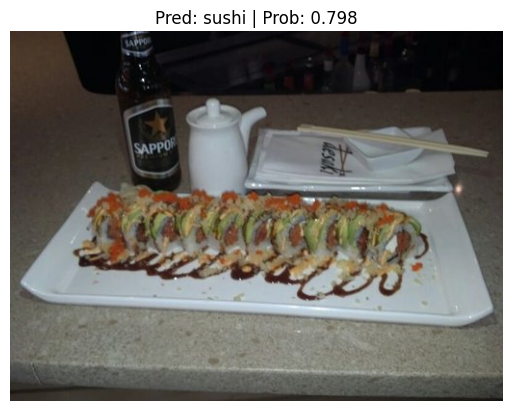

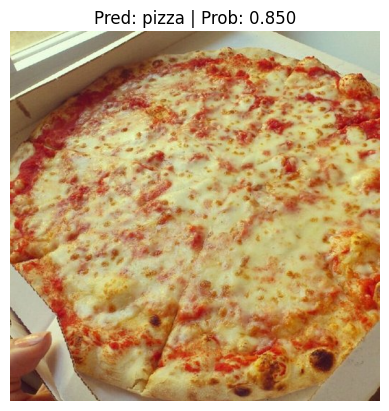

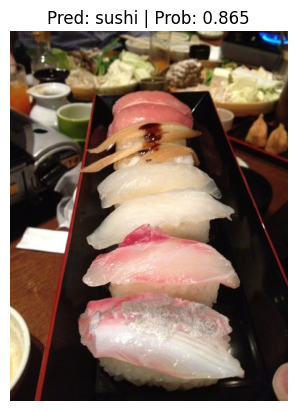

In [64]:
from going_modular.predictions import pred_and_plot_image

# Get a random list of n images paths from the test dataset
import random
num_images_to_plot = 3

test_image_path_list = list(Path(data_20_percent_path / "test").glob("*/*.jpg"))
test_image_path_sample = random.sample(test_image_path_list,
                                       k=num_images_to_plot)

for image_path in test_image_path_sample:
  pred_and_plot_image(model=best_model,
                      image_path=image_path,
                      class_names=class_names,
                      image_size=(224,224))

Download data/pizza.jpg...


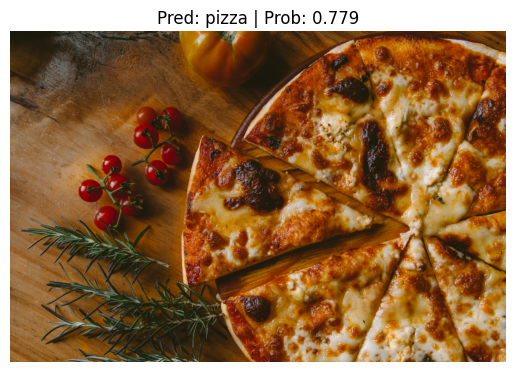

In [69]:
# Making a prediction on a custom image that is not in the custom dataset
custom_image_path = Path("data" , "pizza.jpg")

# Download the image if it does not exist
if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    # Download the image from GitHub
    request = requests.get("https://raw.githubusercontent.com/esraalmaeeni/pytorch-zero-to-mastery-MyPractice/main/images/pizza.jpg")
    print(f"Download {custom_image_path}...")
    f.write(request.content)
else:
  print(f"{custom_image_path} already exists, skipping downloading...")

pred_and_plot_image(model=best_model,
                      image_path=custom_image_path,
                      class_names=class_names,
                      image_size=(224,224))

In [71]:
from google.colab import files

# Zip the folder
!zip -r models.zip models/
!zip -r runs.zip runs/

# Download to your local machine
files.download("models.zip")
files.download("runs.zip")

  adding: models/ (stored 0%)
  adding: models/07_effnetb2_data_20_percent_5_epochs.pth (deflated 8%)
  adding: models/07_effnetb0_data_20_percent_5_epochs.pth (deflated 8%)
  adding: models/07_effnetb2_data_10_percent_5_epochs.pth (deflated 8%)
  adding: models/07_effnetb2_data_10_percent_10_epochs.pth (deflated 8%)
  adding: models/07_effnetb0_data_10_percent_5_epochs.pth (deflated 8%)
  adding: models/07_effnetb0_data_20_percent_10_epochs.pth (deflated 8%)
  adding: models/07_effnetb0_data_10_percent_10_epochs.pth (deflated 8%)
  adding: models/07_effnetb2_data_20_percent_10_epochs.pth (deflated 8%)
updating: runs/ (stored 0%)
updating: runs/Jun28_12-53-19_52c5fd001dbb/ (stored 0%)
updating: runs/Jun28_12-53-19_52c5fd001dbb/Loss_test_loss/ (stored 0%)
updating: runs/Jun28_12-53-19_52c5fd001dbb/Loss_test_loss/events.out.tfevents.1751115209.52c5fd001dbb.427.7 (deflated 12%)
updating: runs/Jun28_12-53-19_52c5fd001dbb/Loss_test_loss/events.out.tfevents.1751115216.52c5fd001dbb.427.12 (de

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>